# Descriptive Analysis
In this notebook we explore and visualize descriptive statistics of our filtered corpus

In [4]:
import pandas as pd
import matplotlib.pyplot as plt
import ast
import os
from collections import Counter
import numpy as np
import pyarrow

In [5]:
import warnings
warnings.filterwarnings("ignore", category=FutureWarning)

In [41]:
df = pd.read_parquet("../../data/metadata_files/GP_opium_filtered.parquet")
print(f"Dataset loaded. Shape: {df.shape}")
display(df.head())

Dataset loaded. Shape: (6413, 11)


,Etext Number,Type,Issued,Title,Language,LoCC,Authors,Opium Keywords,Published Year,Genres,Themes
0,15,Text,1991-05-01,"Moby-Dick; or, The Whale",en,PS,"Melville, Herman","['opium', 'paregoric', 'laudanum']",1851,"[Fiction, Literature, Adventure, Best Books Ev...","[Mentally ill, Psychological fiction, Sea stor..."
1,16,Text,2008-06-25,Peter Pan,en,PR; PZ,"Barrie, J. M. (James Matthew)",['heroin'],1906,"[Children's Literature, Literature, Fiction, S...","[Pirates, Fantasy literature, Fairies, Peter P..."
2,24,Text,2008-06-27,O Pioneers!,en,PS,"Cather, Willa",['poppy'],1913,"[Fiction, History, Culture/Civilization/Societ...","[Swedish Americans, Nebraska, Farm life, Women..."
3,27,Text,1992-03-01,Far from the Madding Crowd,en,PR,"Hardy, Thomas",['heroin'],1874,"[Fiction, Culture/Civilization/Society, Litera...","[Love stories, Farm life, Women farmers, Pasto..."
4,33,Text,1992-06-01,The Scarlet Letter,en,PS,"Hawthorne, Nathaniel",['nepenthe'],1850,"[History, Literature, Fiction, Harvard Classic...","[Puritans, Adultery, Psychological fiction, Re..."


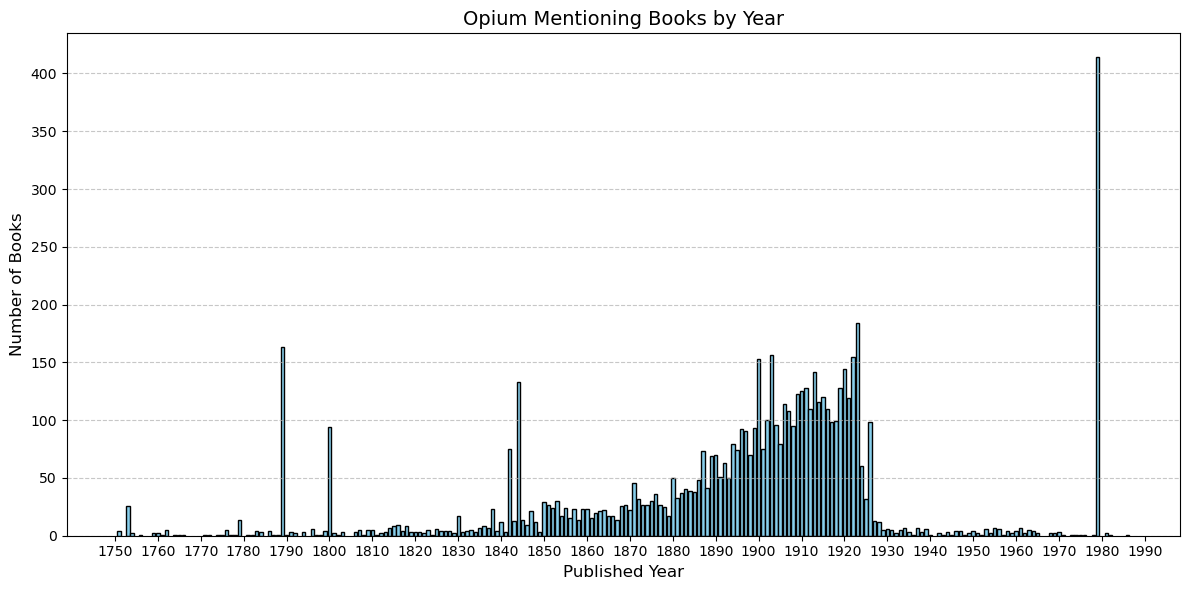

In [7]:
# Books per year distribution
plt.figure(figsize=(12, 6))
years = pd.to_numeric(df['Published Year'], errors='coerce')
year_counts = years.dropna().value_counts().sort_index()
plt.bar(year_counts.index, year_counts.values, color='skyblue', edgecolor='black')
plt.title('Opium Mentioning Books by Year', fontsize=14)
plt.xlabel('Published Year', fontsize=12)
plt.ylabel('Number of Books', fontsize=12)
plt.xticks(range(round(year_counts.index[0], -1), round(year_counts.index[-1], -1) + 10, 10))
plt.grid(axis='y', linestyle='--', alpha=0.7)
plt.tight_layout()
plt.show()

Our data is not uniformly distributed across the years. It is increasing in number after 1850 and significantly drop around 1930 -> we can choose this exact time period for the temporal scope of this study, which covers before the second opium war (1856-1860) to after the first international effort to restrict international opium trade with The Hague Convention (1912)

In [42]:
# Filtering for years of interest:
start_year = 1850
end_year = 1930
prev_nb = df.shape[0]
df = df[df["Published Year"].apply(lambda y: start_year < y & y < end_year)]
print(df.shape)
print(f"We filtered {prev_nb - df.shape[0]} books out, that were not published between {start_year} and {end_year}.")
df.head()

(4986, 11)
We filtered 1427 books out, that were not published between 1850 and 1930.


,Etext Number,Type,Issued,Title,Language,LoCC,Authors,Opium Keywords,Published Year,Genres,Themes
0,15,Text,1991-05-01,"Moby-Dick; or, The Whale",en,PS,"Melville, Herman","['opium', 'paregoric', 'laudanum']",1851,"[Fiction, Literature, Adventure, Best Books Ev...","[Mentally ill, Psychological fiction, Sea stor..."
1,16,Text,2008-06-25,Peter Pan,en,PR; PZ,"Barrie, J. M. (James Matthew)",['heroin'],1906,"[Children's Literature, Literature, Fiction, S...","[Pirates, Fantasy literature, Fairies, Peter P..."
2,24,Text,2008-06-27,O Pioneers!,en,PS,"Cather, Willa",['poppy'],1913,"[Fiction, History, Culture/Civilization/Societ...","[Swedish Americans, Nebraska, Farm life, Women..."
3,27,Text,1992-03-01,Far from the Madding Crowd,en,PR,"Hardy, Thomas",['heroin'],1874,"[Fiction, Culture/Civilization/Society, Litera...","[Love stories, Farm life, Women farmers, Pasto..."
5,36,Text,2004-10-01,The War of the Worlds,en,PR,"Wells, H. G. (Herbert George)",['black smoke'],1897,"[History, Fiction, Science-Fiction & Fantasy, ...","[Martians, Space warfare, Mars (Planet), War s..."


!! Edit: After close reading we also decided to remove 'poppy' and 'black smoke' from the list, since there were too many false positive that were describing the environment (poppy tree, black smoke from pollution), character name ("Poppy") or other elements that wasn't opium-related -> we will also remove that

In [43]:
import ast
df['Opium Keywords'] = df['Opium Keywords'].apply(ast.literal_eval)

kw_to_remove = {'black smoke', 'poppy'}
n_before = len(df)
# remove unwanted keywords from each list
df['Opium Keywords'] = df['Opium Keywords'].apply(
    lambda kws: [kw for kw in kws if kw not in kw_to_remove]
)
# drop rows where no keywords remain
df = df[df['Opium Keywords'].str.len() > 0]
n_after = len(df)
print(n_after)
print(f"We filtered {n_before - n_after} books with keywords: {', '.join(kw_to_remove)}.")

4378
We filtered 608 books with keywords: black smoke, poppy.


In [ ]:
df.to_parquet('../../data/metadata_files/GP_opium_filtered_1850_1930.parquet')

First we look at the books and their opium mentions:

=== Opium Mentions Analytics ===
Total Books: 4378
Total Opium Mentions: 6174
Average Mentions per Book: 1.41
Median Mentions per Book: 1.0
Max Mentions in one Book: 8


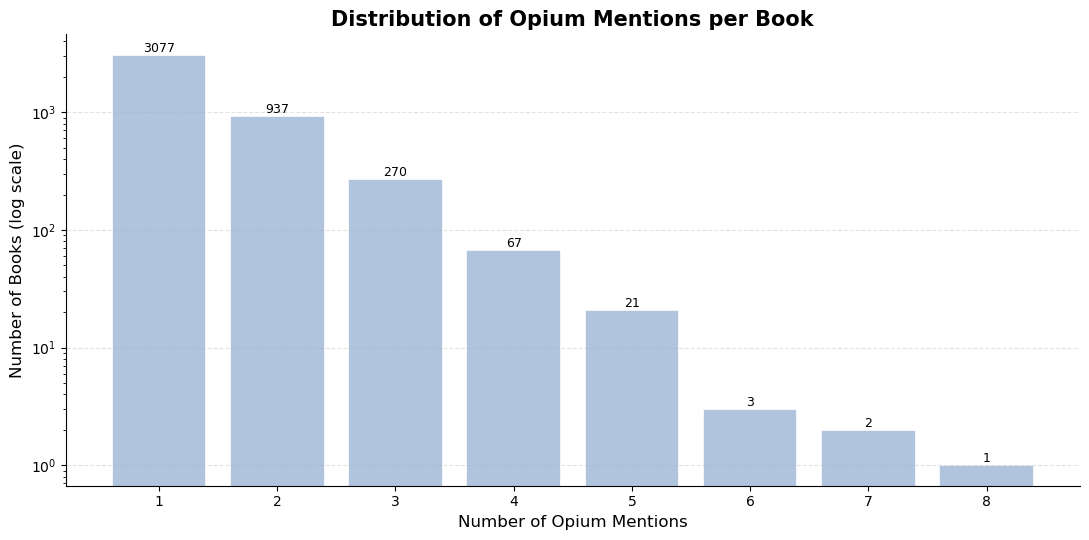

In [47]:
# Opium Mentions Aggregation
df['Opium_Mention_Count'] = df['Opium Keywords'].apply(len)

print("=== Opium Mentions Analytics ===")
print(f"Total Books: {len(df)}")
print(f"Total Opium Mentions: {df['Opium_Mention_Count'].sum()}")
print(f"Average Mentions per Book: {df['Opium_Mention_Count'].mean():.2f}")
print(f"Median Mentions per Book: {df['Opium_Mention_Count'].median()}")
print(f"Max Mentions in one Book: {df['Opium_Mention_Count'].max()}")

# Count books for each exact mention count
counts = (
    df['Opium_Mention_Count']
    .value_counts()
    .sort_index()
)

# Make sure missing integer values still appear on x-axis
full_index = range(1, df['Opium_Mention_Count'].max() + 1)
counts = counts.reindex(full_index, fill_value=0)

plt.figure(figsize=(11, 5.5))

bars = plt.bar(
    counts.index,
    counts.values,
    color='lightsteelblue',
    edgecolor='white',
    linewidth=1.2
)

plt.yscale('log')
plt.title('Distribution of Opium Mentions per Book', fontsize=15, weight='bold')
plt.xlabel('Number of Opium Mentions', fontsize=12)
plt.ylabel('Number of Books (log scale)', fontsize=12)

plt.xticks(counts.index)
plt.grid(axis='y', linestyle='--', alpha=0.35)
plt.gca().spines[['top', 'right']].set_visible(False)

# Optional labels above bars
for bar in bars:
    height = bar.get_height()
    if height > 0:
        plt.text(
            bar.get_x() + bar.get_width() / 2,
            height,
            int(height),
            ha='center',
            va='bottom',
            fontsize=9
        )

plt.tight_layout()
plt.show()

(Top) themes and genres - Absolute count:

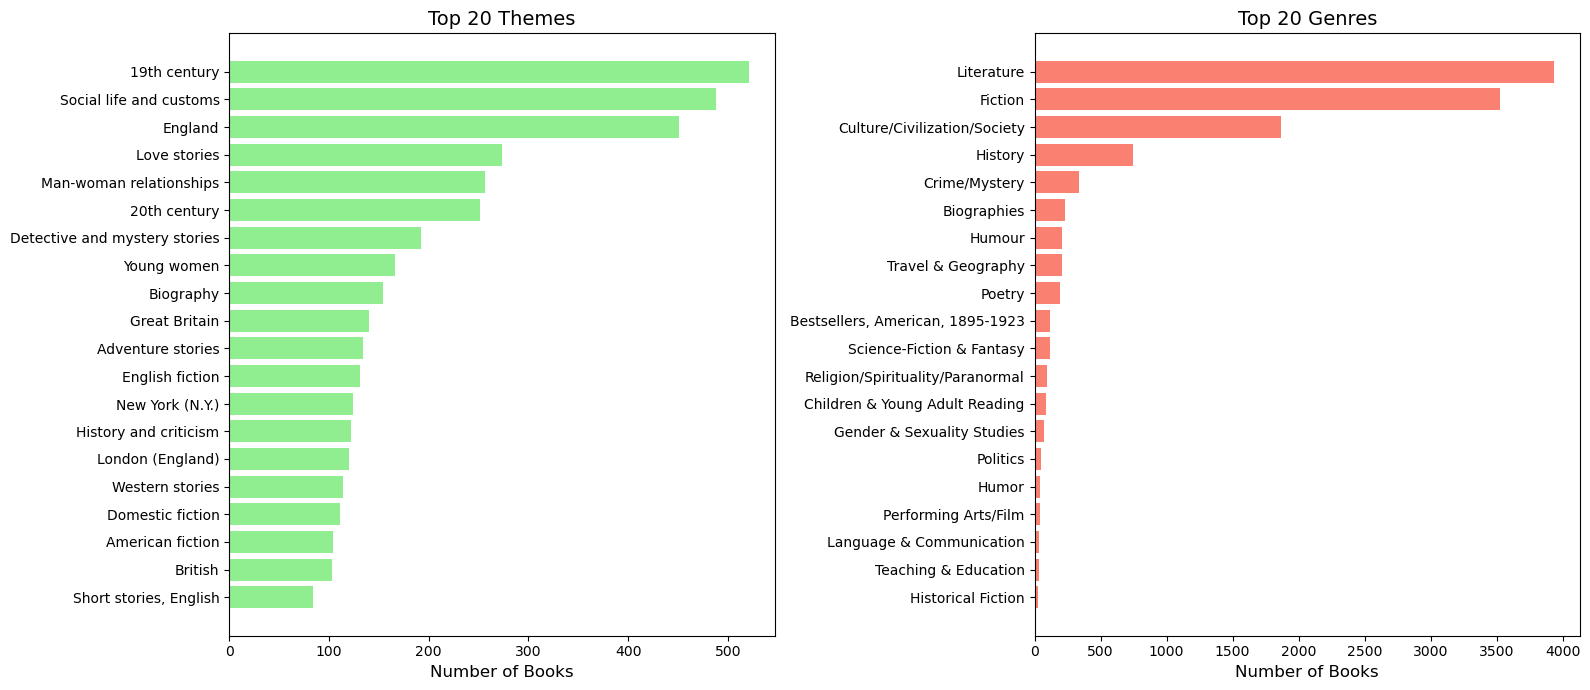

In [48]:
# Top Themes and Genres
fig, axes = plt.subplots(1, 2, figsize=(16, 7))

def parse_list(k):
    if isinstance(k, np.ndarray): return k.tolist()
    if isinstance(k, list): return k
    try:
        res = ast.literal_eval(k)
        return res if isinstance(res, list) else [res]
    except:
        return [x.strip() for x in str(k).split(',')]

all_themes = df['Themes'].apply(parse_list).explode().dropna()
top_themes = all_themes.value_counts().head(20)

axes[0].barh(top_themes.index[::-1], top_themes.values[::-1], color='lightgreen')
axes[0].set_title('Top 20 Themes', fontsize=14)
axes[0].set_xlabel('Number of Books', fontsize=12)

all_genres = df['Genres'].apply(parse_list).explode().dropna()
top_genres = all_genres.value_counts().head(20)

axes[1].barh(top_genres.index[::-1], top_genres.values[::-1], color='salmon')
axes[1].set_title('Top 20 Genres', fontsize=14)
axes[1].set_xlabel('Number of Books', fontsize=12)

plt.tight_layout()
plt.show()

Relative (percentage) count:

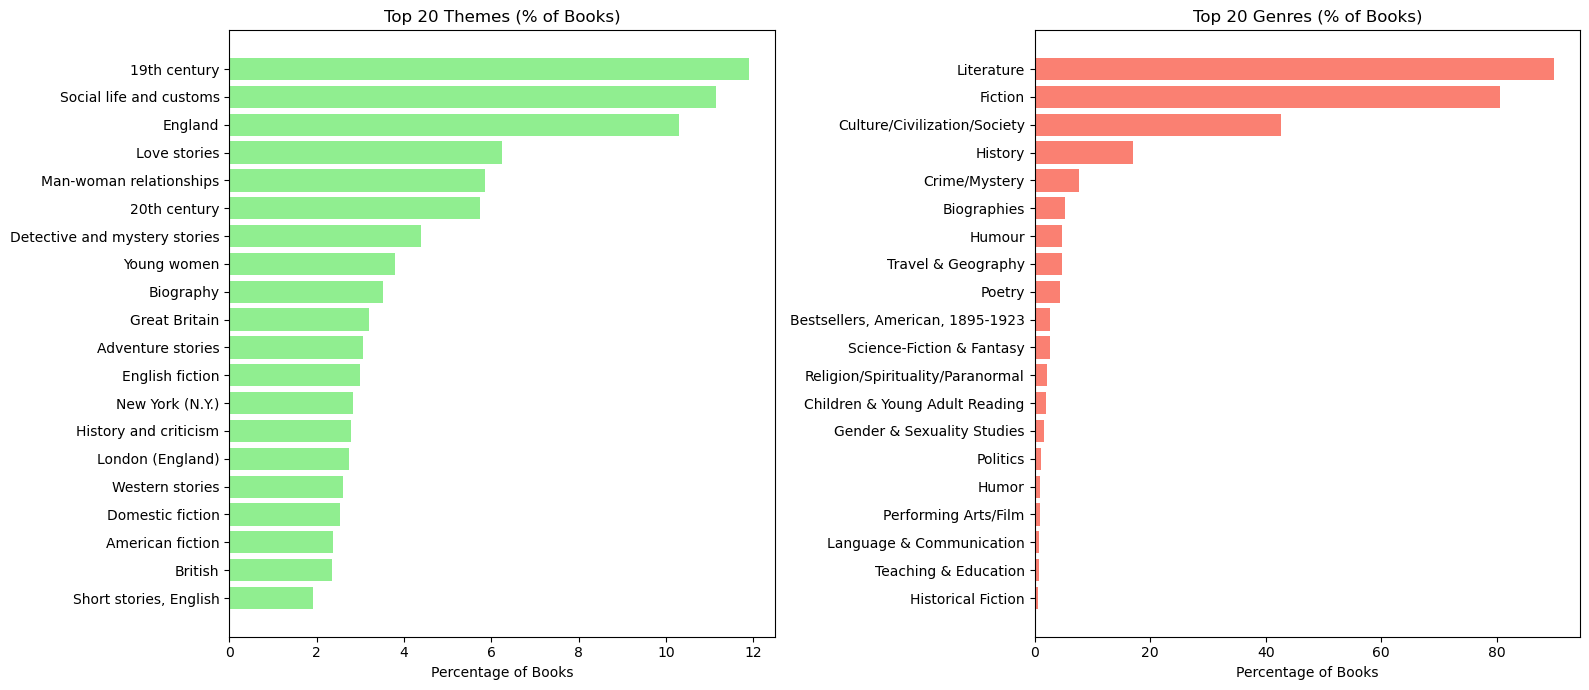

In [49]:
n_books = len(df)
top_themes_pct = top_themes / n_books * 100
top_genres_pct = top_genres / n_books * 100

fig, axes = plt.subplots(1, 2, figsize=(16, 7))

# Themes
axes[0].barh(top_themes_pct.index[::-1], top_themes_pct.values[::-1], color='lightgreen')
axes[0].set_title('Top 20 Themes (% of Books)')
axes[0].set_xlabel('Percentage of Books')

# Genres
axes[1].barh(top_genres_pct.index[::-1], top_genres_pct.values[::-1], color='salmon')
axes[1].set_title('Top 20 Genres (% of Books)')
axes[1].set_xlabel('Percentage of Books')

plt.tight_layout()
plt.show()

Genres are concentrated around 'Literature' and 'Fiction' (making up >80%, fair since it's our broad main focus), and themes are more diverse

Note that themes and genre can overlap (one book can have multiple themes and genres) - so we can look at their co-occurance, and also accumulative coverage to see dominant factors within these attributes

In [50]:
TOP_N_THEMES = 20 
TOP_N_GENRES = 20

top_theme_list = all_themes.value_counts().head(TOP_N_THEMES).index
top_genre_list = all_genres.value_counts().head(TOP_N_GENRES).index

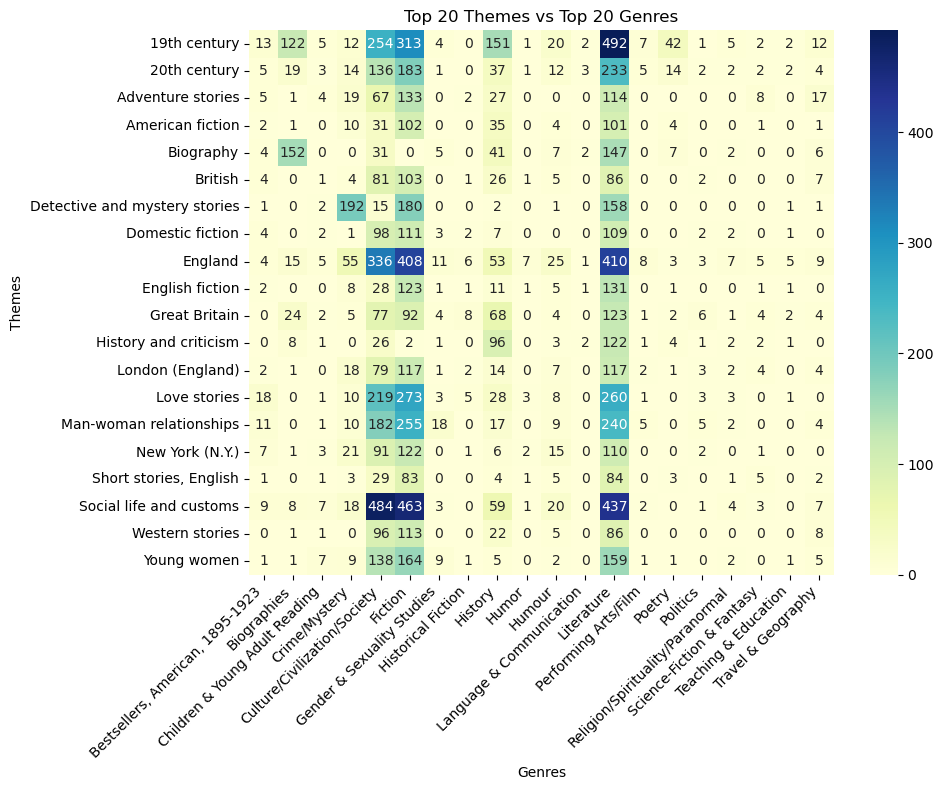

In [51]:
import seaborn as sns

df_exploded = df.explode('Themes').explode('Genres')

# Filter BEFORE building matrix
filtered = df_exploded[
    df_exploded['Themes'].isin(top_theme_list) &
    df_exploded['Genres'].isin(top_genre_list)
]
filtered = filtered.reset_index(drop=True)

co_matrix = pd.crosstab(
    filtered['Themes'],
    filtered['Genres']
)

plt.figure(figsize=(10, 8))
sns.heatmap(
    co_matrix,
    cmap='YlGnBu',
    annot=True,
    fmt='d'
)

plt.title(f'Top {TOP_N_THEMES} Themes vs Top {TOP_N_GENRES} Genres')
plt.xticks(rotation=45, ha='right')
plt.tight_layout()
plt.show()

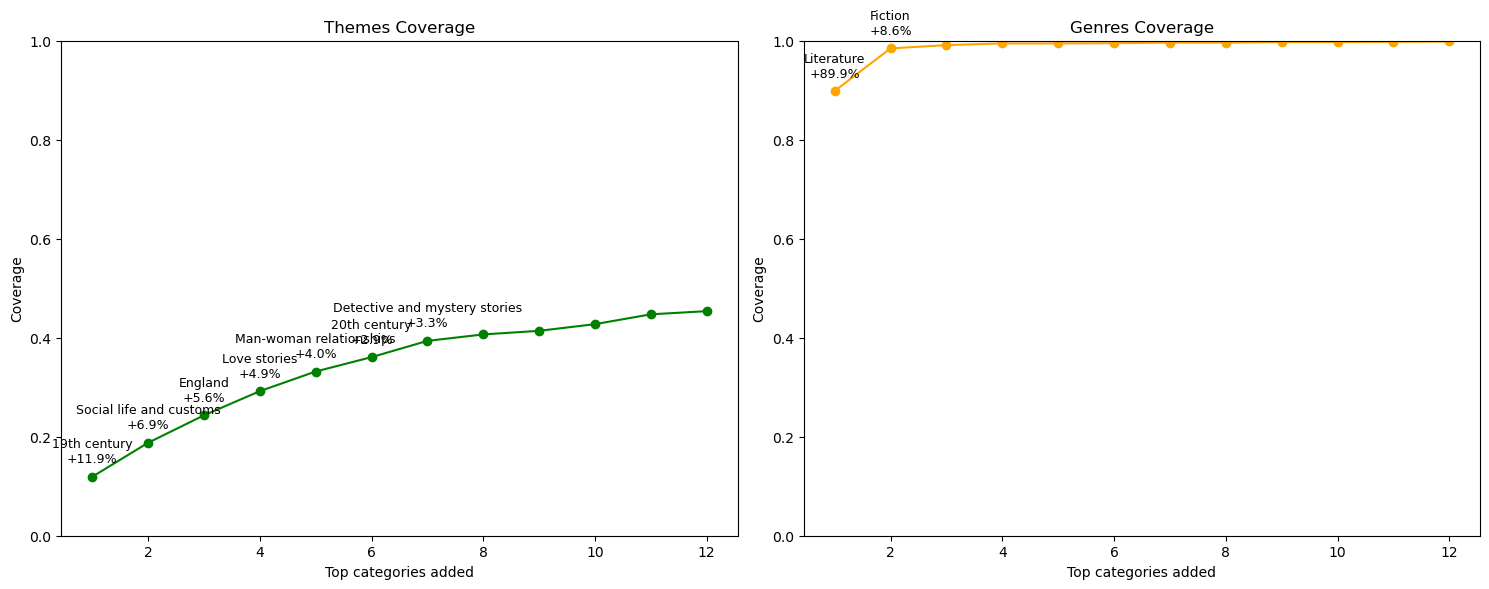

In [52]:
def cumulative_coverage_with_gain(series, top_n=12):
    parsed = series.apply(parse_list)

    all_items = parsed.explode()
    top_items = all_items.value_counts().head(top_n).index.tolist()

    coverage = []
    gains = []
    selected = set()

    prev_cov = 0

    for item in top_items:
        selected.add(item)

        covered = parsed.apply(lambda x: any(i in x for i in selected))
        curr_cov = covered.mean()

        coverage.append(curr_cov)
        gains.append(curr_cov - prev_cov)

        prev_cov = curr_cov

    return top_items, coverage, gains

themes, theme_cov, theme_gain = cumulative_coverage_with_gain(df['Themes'])
genres, genre_cov, genre_gain = cumulative_coverage_with_gain(df['Genres'])

fig, axes = plt.subplots(1, 2, figsize=(15, 6))

def plot_with_labels(ax, items, cov, gains, title, color):
    x = range(1, len(items)+1)
    ax.plot(x, cov, marker='o', color=color)

    for i, (item, c, g) in enumerate(zip(items, cov, gains)):
        # Only label meaningful jumps
        if g > 0.02:  # tweak threshold
            ax.annotate(
                f"{item}\n+{g:.1%}",
                (i+1, c),
                textcoords="offset points",
                xytext=(0,10),
                ha='center',
                fontsize=9
            )

    ax.set_title(title)
    ax.set_ylim(0, 1)
    ax.set_xlabel("Top categories added")
    ax.set_ylabel("Coverage")

plot_with_labels(axes[0], themes, theme_cov, theme_gain, "Themes Coverage", "green")
plot_with_labels(axes[1], genres, genre_cov, genre_gain, "Genres Coverage", "orange")

plt.tight_layout()
plt.show()

Now we look a bit deeper into the opium terms themselves:

In [55]:
term_counts

Counter({'heroin': 4378})

In [57]:
df['Opium Keywords']

0       [opium, paregoric, laudanum]
1                           [heroin]
3                           [heroin]
6                    [opium, heroin]
7                           [heroin]
                    ...             
6396                 [opium, heroin]
6403                        [heroin]
6406               [heroin, anodyne]
6407                        [heroin]
6408                 [opium, heroin]
Name: Opium Keywords, Length: 4378, dtype: object

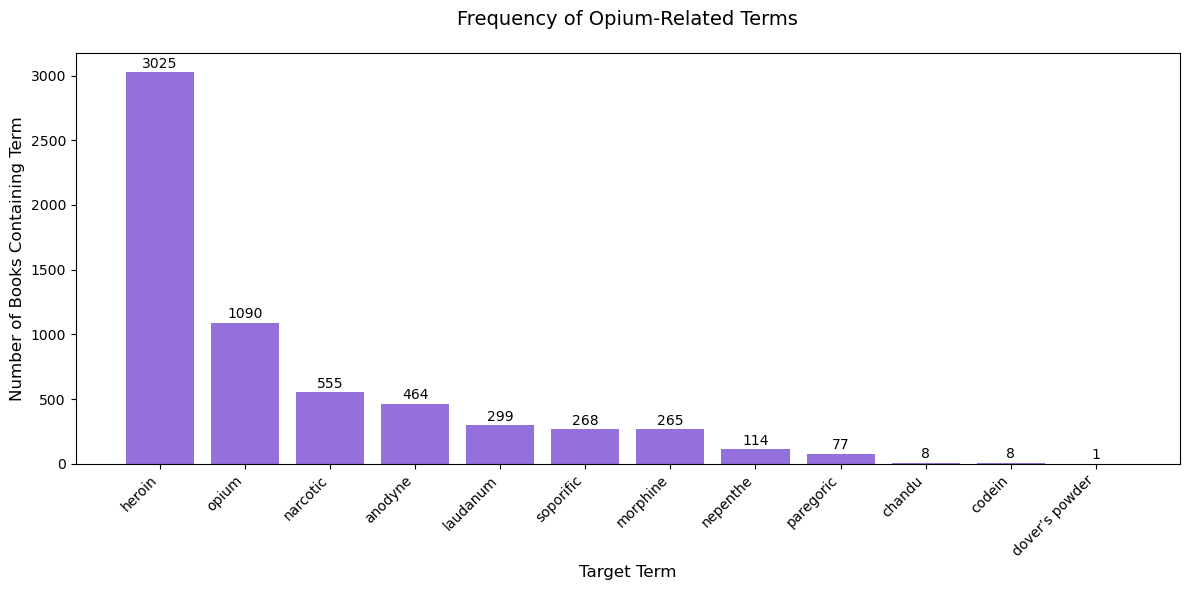

In [64]:
# Term Frequency
term_counts = Counter()
for row in df['Opium Keywords']:
    term_counts.update(row)

top_terms = dict(term_counts.most_common(12))

plt.figure(figsize=(12, 6))
bars = plt.bar(top_terms.keys(), top_terms.values(), color='mediumpurple')
plt.title('Frequency of Opium-Related Terms', fontsize=14, pad=20)
plt.xlabel('Target Term', fontsize=12)
plt.ylabel('Number of Books Containing Term', fontsize=12)
plt.xticks(rotation=45, ha='right')

for bar in bars:
    yval = bar.get_height()
    plt.text(bar.get_x() + bar.get_width()/2, yval + 10, int(yval), ha='center', va='bottom', fontsize=10)
    
plt.tight_layout()
plt.show()


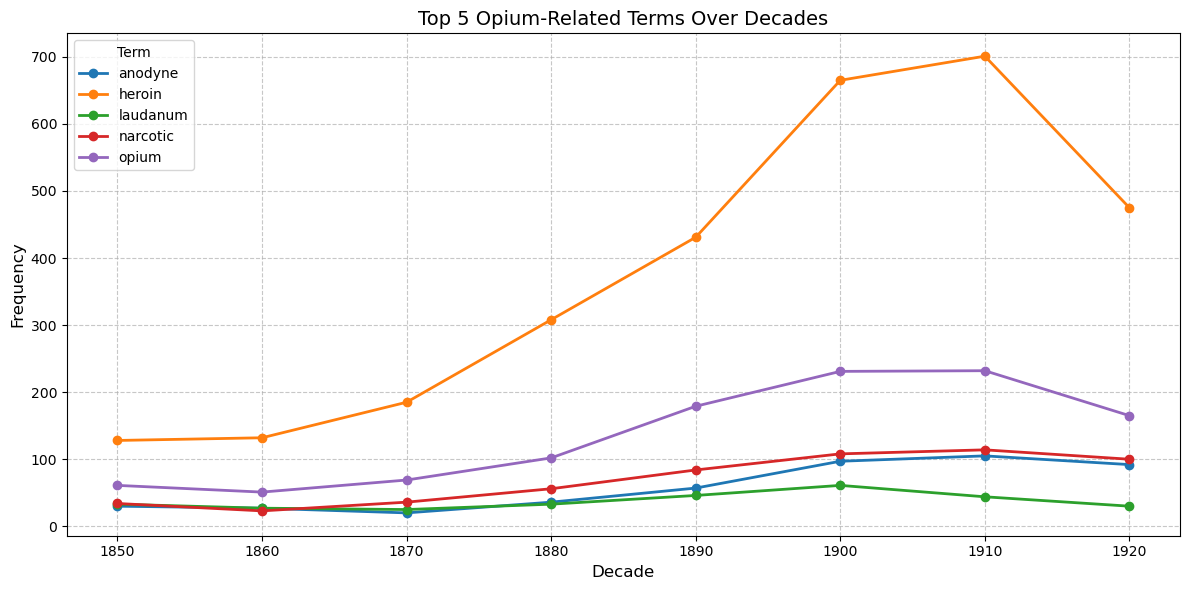

In [67]:
# Terms Over Time (Decades)
df_terms = df.dropna(subset=['Published Year', 'Opium Keywords']).copy()
df_terms['Published Year'] = pd.to_numeric(df_terms['Published Year'], errors='coerce')
df_terms = df_terms.dropna(subset=['Published Year'])
df_terms['decade'] = (df_terms['Published Year'] // 10) * 10

records = []
for idx, row in df_terms.iterrows():
    kws = row['Opium Keywords']
    decade = row['decade']
    for k in kws:
        records.append({'decade': decade, 'term': k})
                
df_expanded = pd.DataFrame(records)
if not df_expanded.empty:
    top_5_terms = df_expanded['term'].value_counts().head(5).index.tolist()
    df_top5 = df_expanded[df_expanded['term'].isin(top_5_terms)]
    ct = pd.crosstab(df_top5['decade'], df_top5['term'])
    
    plt.figure(figsize=(12, 6))
    for term in ct.columns:
        plt.plot(ct.index, ct[term], marker='o', linewidth=2, label=term)
        
    plt.title('Top 5 Opium-Related Terms Over Decades', fontsize=14)
    plt.xlabel('Decade', fontsize=12)
    plt.ylabel('Frequency', fontsize=12)
    plt.legend(title='Term')
    plt.grid(True, linestyle='--', alpha=0.7)
    plt.tight_layout()
    plt.show()


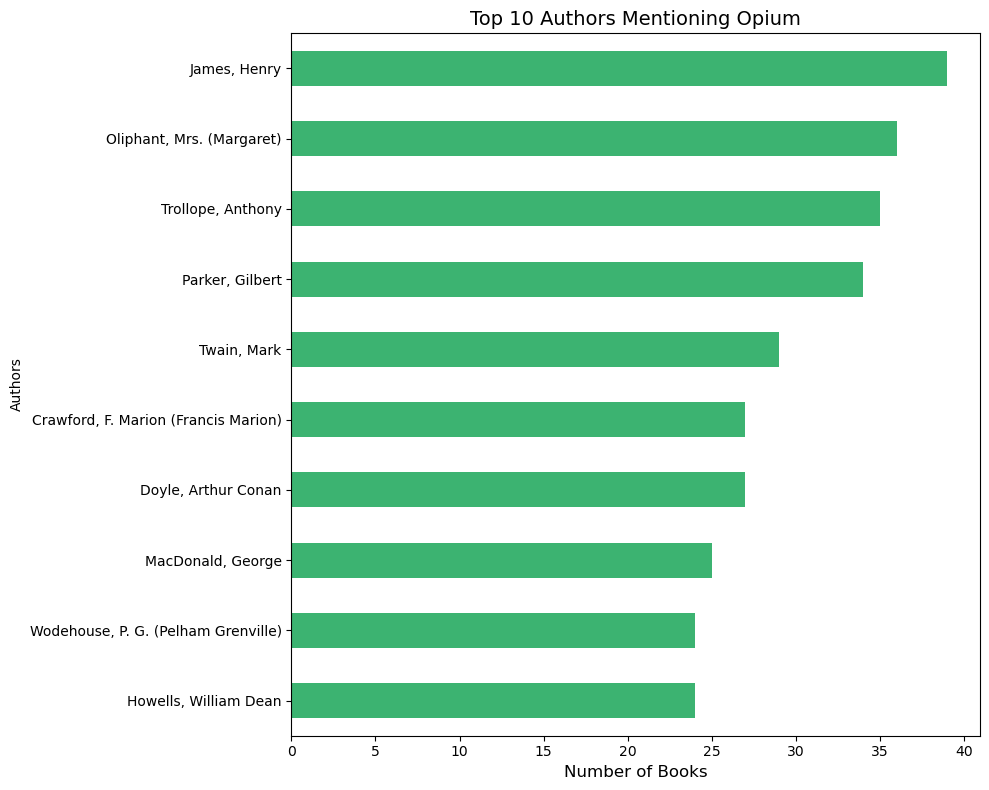

In [68]:
# Top Authors
df_authors = df.dropna(subset=['Authors']).copy()
all_authors = df_authors['Authors'].str.split(';').explode().str.strip()
top_authors = all_authors.value_counts().head(10)

plt.figure(figsize=(10, 8))
top_authors.sort_values().plot(kind='barh', color='mediumseagreen')
plt.title('Top 10 Authors Mentioning Opium', fontsize=14)
plt.xlabel('Number of Books', fontsize=12)
plt.tight_layout()
plt.show()
